# Analyzing Blood Supply Chain Leg Utilization
 --- For WSC2026

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm.notebook import trange

%load_ext autoreload
%autoreload 2

%aimport scratch.logistics_data
%aimport scratch.convenience_functions

logi = scratch.logistics_data
cf = scratch.convenience_functions

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.5, context="paper", font='Nimbus Roman')

In [3]:

excel_file = "scratch/data_files/input/Inter Centre timetable easy access.v8FBO.xlsx"
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
next_day = {
    'Monday': 'Tuesday',
    'Tuesday': 'Wednesday',
    'Wednesday': 'Thursday',
    'Thursday': 'Friday',
    'Friday': 'Saturday',
    'Saturday': 'Sunday',
    'Sunday': 'Monday'
}
connected_pairs = [('Manchester', 'Newcastle'), ('Manchester', 'Barnsley'), ('Manchester', 'Liverpool'), ('Manchester', 'Lancaster'),
                   ('Manchester', 'Birmingham'), ('Birmingham', 'Colindale'),
                   ('Manchester', 'Filton'),
                   ('Filton', 'Birmingham'), ('Filton', 'Oxford'), ('Filton', 'Southampton'), ('Filton', 'Plymouth'),
                   ('Oxford', 'Birmingham'),
                   ('Filton', 'Tooting'), ('Tooting', 'Basildon'), ('Basildon', 'Cambridge'), 
                   ('Tooting', 'Southampton'),
                   ('Colindale', 'Cambridge'), ('Colindale', 'Basildon'), ('Colindale', 'Tooting'),]
bi_directional_pairs = [(a, b) for a, b in connected_pairs] + [(b, a) for a, b in connected_pairs]

event_colors = {'Blood Matching': 'orange',
                'Arrival': 'green',
                'Departure': 'blue',}



## Loading the Data

In [4]:
timetable_df = logi.load_logistics_data_from_excel(excel_file,
                                                   sheet_name='Route data',
                                                   columns_to_read='A:J',
                                                   skiprows=3,
                                                   )

## Add New Routes

The new routes added to the timetable are as follows:

| From | Depart | Frequency | To | Arrive | Mode | Prime | Weekly Frequency | Travel Time | Cost |
|------|--------|-----------|----|--------|------|-------|------------------|-------------|------|
| Filton | 07:00 | Mon-Sat | Manchester | 10:30 | NHSBT | | 6 | 03:30 | |
| Manchester | 11:30 | Mon-Sat | Filton | 15:00 | NHSBT | | 6 | 03:30 | |
| Birmingham | 01:00 | Mon-Fri | Oxford | 02:45 | Courier | Cone run | 5 | 01:45 | 0 |

With the last route, (i.e., Birmingham to Oxford Cones run), I will edit this so that the Mode is "NHSBT" instead of "Courier" so that it is not filtered out.
It is being added because Kirk said
> We often piggyback on the Cones Run Monday to Friday as its Free


In [5]:
new_routes_df = pd.DataFrame({
    'From': ['Filton', 'Manchester', 'Birmingham', ],
    'Depart': ['07:00:00', '11:30:00', '01:00:00'],
    'Frequency': ['Mon-Sat', 'Mon-Sat', 'Mon-Fri'],
    'To': ['Manchester', 'Filton', 'Oxford'],
    'Arrive': ['10:30:00', '15:00:00', '02:45:00'],
    'Mode': ['NHSBT', 'NHSBT', 'NHSBT'],
    # 'Prime': ['', '', ],
    'Weekly frequency': [6, 6, 5],
    'Travel Time': ['03:30:00', '03:30:00', '01:45:00'],
    # 'Cost': [np.nan, np.nan, ],
})
updated_timetable_df = pd.concat([timetable_df, new_routes_df], ignore_index=True)

In [6]:
timetable_df, old_timetable_df = updated_timetable_df, timetable_df

## Cleaning

In [7]:
timetable_df_clean = logi.clean_data(timetable_df.copy())
# timetable_df_clean.head()

## Munging & Wrangling
### Removing Indirect Routes
There are journeys that are not direct routes, such as those that go through multiple stops. For example, the North/South run that goes from Liverpool through Manchester, then Birmingham, and finally to Colindale.
This is duplicated in the dataset, with the sub-journeys listed as well as the full journey. The full journey is not needed, as it is not a 'direct' route. We will remove these indirect routes from the dataset.

In [8]:
unique_pairs = timetable_df_clean[['From', 'To']].drop_duplicates()
len(unique_pairs)

43

In [9]:
# directly connected pairs of locations
# These are the pairs of locations that have a direct route between them
print(len(connected_pairs))
print(len(bi_directional_pairs))

19
38


In [10]:
bi_directional_pairs_str = [f"{a}-{b}" for a, b in bi_directional_pairs]
timetable_df_clean['Route'] = timetable_df_clean.apply(lambda row: f"{row['From']}-{row['To']}", axis=1)
timetable_df_clean['Route'] = timetable_df_clean['Route'].astype(str)


In [11]:
timetable_df_route_segments = timetable_df_clean[timetable_df_clean['Route'].isin(bi_directional_pairs_str)].copy()
len(timetable_df_route_segments)

328

### Fixing Crossing Midnight Errors

Where the timing is probably, e.g., Tuesday morning instead of Monday morning

- Filton to Birmingham 02:45 to 06:15 (Mon-Fri) & 01:00 to 04:00 (Sat) & 01:00 to 02:45 (Sun)
- Tooting to Basildon 01:00 to 02:30 (Mon-Fri) & 02:00 to 03:30 (Sat-Sun)
- Basildon to Cambridge 03:00 to 04:00 (Mon-Fri) & 03:30 to 05:00 (Sat-Sun)
- Tooting to Cambridge 01:00 to 05:00 (Mon-Fri) & 02:00 to 05:00 (Sat-Sun)
- Plymouth to Filton 00:30 to 03:30 (Mon-Fri) & 13:30 to 16:30 (Sun)
- Southampton to Filton 23:45 to 02:00 (Mon-Fri) & 02:10 to 04:10 (Sat-Sun)
- Tooting to Filton 03:00 to 06:00 (Mon-Fri) & 00:00 to 04:10 (Sat-Sun)
- Birmingham to Liverpool 01:00 to 04:30 (Mon-Fri)
- Manchester to Liverpool 03:30 to 04:30 (Mon-Fri)
- Newcastle to Manchester 00:40 to 04:00 (Mon-Fri) & 01:40 to 05:00 (Sat & Sun)
- Filton to Oxford 19:45 to 21:45 (Mon-Fri) & 01:00 to 02:30 (Sat)
- Tooting to Southampton 00:00 to 01:30 (Sat-Sun)
- Oxford to Birmingham 02:45 to 04:15 (Sat)
- Birmingham to Oxford 01:00 to 02:45 (Mon-Fri)

In [12]:
# Convert 'Depart' and 'Arrive' columns to datetime.time objects (times only)
timetable_df_route_segments.loc[:, 'Depart_time'] = pd.to_datetime(timetable_df_route_segments['Depart'].astype(str), format='%H:%M:%S').dt.time
timetable_df_route_segments.loc[:, 'Arrive_time'] = pd.to_datetime(timetable_df_route_segments['Arrive'].astype(str), format='%H:%M:%S').dt.time

# timetable_df_route_segments[['Depart', 'Depart_time', 'Arrive', 'Arrive_time']].head()

In [13]:
misaligned_routes = ['Filton-Birmingham', 'Tooting-Basildon', 'Basildon-Cambridge',
                     'Tooting-Cambridge', 'Plymouth-Filton', 'Southampton-Filton',
                     'Tooting-Filton', 'Birmingham-Liverpool', 'Manchester-Liverpool',
                     'Newcastle-Manchester', 'Filton-Oxford', 'Tooting-Southampton',
                     'Oxford-Birmingham', 'Birmingham-Oxford',]
night_cutoff = pd.to_datetime("03:45:00", format='%H:%M:%S').time()
midnight_cutoff = pd.to_datetime("00:00:00").time()
# frequency_tag = 'Mond'
# night_cutoff, midnight_cutoff

In [14]:
mask = (
    timetable_df_route_segments['Route'].isin(misaligned_routes) &
    (pd.to_datetime(timetable_df_route_segments['Depart_time'], format='%H:%M:%S').dt.time >= midnight_cutoff) &
    (pd.to_datetime(timetable_df_route_segments['Depart_time'], format='%H:%M:%S').dt.time <= night_cutoff)
)
timetable_df_final = timetable_df_route_segments.copy()
timetable_df_final['Depart_time'] = pd.to_datetime(timetable_df_final['Depart_time'], format='%H:%M:%S').dt.time
timetable_df_final['Arrive_time'] = pd.to_datetime(timetable_df_final['Arrive_time'], format='%H:%M:%S').dt.time
timetable_df_final.loc[mask, 'Day'] = timetable_df_final.loc[mask, 'Day'].apply(logi.shift_day)
timetable_df_final.reset_index(drop=True, inplace=True)

In [15]:
timetable_df_final

,From,Depart,Frequency,To,Arrive,Mode,Prime,Weekly frequency,Travel Time,Cost,Day,Route,Depart_time,Arrive_time
0,Barnsley,22:15:00,Saturday,Manchester,23:30:00,NHSBT,BMV,1.0,01:15:00,NaN,Saturday,Barnsley-Manchester,22:15:00,23:30:00
1,Barnsley,22:15:00,Sunday,Manchester,23:30:00,NHSBT,BMV,1.0,01:15:00,NaN,Sunday,Barnsley-Manchester,22:15:00,23:30:00
2,Barnsley,19:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,20:15:00,BMV,BMV,5.0,01:15:00,NaN,Monday,Barnsley-Manchester,19:00:00,20:15:00
3,Barnsley,19:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,20:15:00,BMV,BMV,5.0,01:15:00,NaN,Tuesday,Barnsley-Manchester,19:00:00,20:15:00
4,Barnsley,19:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,20:15:00,BMV,BMV,5.0,01:15:00,NaN,Wednesday,Barnsley-Manchester,19:00:00,20:15:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,Birmingham,01:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Oxford,02:45:00,NHSBT,NaN,5.0,01:45:00,NaN,Tuesday,Birmingham-Oxford,01:00:00,02:45:00
324,Birmingham,01:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Oxford,02:45:00,NHSBT,NaN,5.0,01:45:00,NaN,Wednesday,Birmingham-Oxford,01:00:00,02:45:00
325,Birmingham,01:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Oxford,02:45:00,NHSBT,NaN,5.0,01:45:00,NaN,Thursday,Birmingham-Oxford,01:00:00,02:45:00
326,Birmingham,01:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Oxford,02:45:00,NHSBT,NaN,5.0,01:45:00,NaN,Friday,Birmingham-Oxford,01:00:00,02:45:00


### Calculate the Journey Duration in Minutes

In [16]:
# Calculate the duration between Depart_time and Arrive_time
# Note: This assumes that 'Depart_time' and 'Arrive_time' are in the same day unless specified otherwise.
# If 'Arrive_time' is earlier than 'Depart_time', it is assumed to be the next day.
# Assume 'Depart_time' and 'Arrive_time' are datetime.time objects

# Convert to datetime64[ns] using a dummy date (e.g., 1900-01-01)
dummy_date = pd.to_datetime('1900-01-01')
df = timetable_df_final.copy()

depart_dt = pd.to_datetime(df['Depart_time'].astype(str), format='%H:%M:%S')
arrive_dt = pd.to_datetime(df['Arrive_time'].astype(str), format='%H:%M:%S')

# Handle cross-midnight durations (add a day if arrival is before departure)
arrive_dt_corrected = arrive_dt.where(arrive_dt >= depart_dt, arrive_dt + pd.Timedelta(days=1))

# Compute duration
df['duration'] = arrive_dt_corrected - depart_dt

# Optional: Convert to total seconds or minutes
df['Duration_minutes'] = df['duration'].dt.total_seconds() / 60


In [17]:
df['Day Arrival'] = df['Day']

# Find rows where arrival is before departure (cross-midnight journeys)
arrival_before_departure = pd.to_datetime(df['Arrive_time'], format='%H:%M:%S') < pd.to_datetime(df['Depart_time'], format='%H:%M:%S')

# Update Day Arrival for those rows
df.loc[arrival_before_departure, 'Day Arrival'] = df.loc[arrival_before_departure, 'Day'].map(next_day)

In [18]:
day_cat = pd.Categorical(df['Day'], categories=day_order, ordered=True)

df['Day'] = df['Day'].astype(day_cat.dtype)
df['Day Arrival'] = df['Day Arrival'].astype(day_cat.dtype)

# Sort by 'To', then 'Day', then 'Arrive_time'
# df_dest_sorted = df.assign(Day=day_cat).sort_values(['To', 'Day', 'Arrive_time'], ascending=[True, True, True]).reset_index(drop=True)
df_dest_sorted = df.sort_values(['To', 'Day Arrival', 'Arrive_time'], ascending=[True, True, True]).reset_index(drop=True)
df_dest_sorted

,From,Depart,Frequency,To,Arrive,Mode,Prime,Weekly frequency,Travel Time,Cost,Day,Route,Depart_time,Arrive_time,duration,Duration_minutes,Day Arrival
0,Manchester,16:30:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Barnsley,18:15:00,NHSBT,BMV,5.0,01:45:00,NaN,Monday,Manchester-Barnsley,16:30:00,18:15:00,0 days 01:45:00,105.0,Monday
1,Manchester,21:45:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Barnsley,23:00:00,NHSBT,BMV,5.0,01:15:00,NaN,Monday,Manchester-Barnsley,21:45:00,23:00:00,0 days 01:15:00,75.0,Monday
2,Manchester,16:30:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Barnsley,18:15:00,NHSBT,BMV,5.0,01:45:00,NaN,Tuesday,Manchester-Barnsley,16:30:00,18:15:00,0 days 01:45:00,105.0,Tuesday
3,Manchester,21:45:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Barnsley,23:00:00,NHSBT,BMV,5.0,01:15:00,NaN,Tuesday,Manchester-Barnsley,21:45:00,23:00:00,0 days 01:15:00,75.0,Tuesday
4,Manchester,16:30:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Barnsley,18:15:00,NHSBT,BMV,5.0,01:45:00,NaN,Wednesday,Manchester-Barnsley,16:30:00,18:15:00,0 days 01:45:00,105.0,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,Filton,20:45:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Tooting,23:45:00,BMV,BMV,5.0,03:00:00,NaN,Friday,Filton-Tooting,20:45:00,23:45:00,0 days 03:00:00,180.0,Friday
324,Filton,20:45:00,Saturday,Tooting,23:15:00,NHSBT,BMV,1.0,02:30:00,NaN,Saturday,Filton-Tooting,20:45:00,23:15:00,0 days 02:30:00,150.0,Saturday
325,Colindale,22:30:00,Saturday,Tooting,23:30:00,NHSBT,Stock,1.0,01:00:00,NaN,Saturday,Colindale-Tooting,22:30:00,23:30:00,0 days 01:00:00,60.0,Saturday
326,Filton,20:45:00,Sunday,Tooting,23:15:00,NHSBT,BMV,1.0,02:30:00,NaN,Sunday,Filton-Tooting,20:45:00,23:15:00,0 days 02:30:00,150.0,Sunday


In [19]:
# Sort by 'From', then 'Day', then 'Depart_time'
# df_source_sorted = df.assign(Day=day_cat).sort_values(['From', 'Day', 'Depart_time'], ascending=[True, True, True]).reset_index(drop=True)
df_source_sorted = df.sort_values(['From', 'Day', 'Depart_time'], ascending=[True, True, True]).reset_index(drop=True)
df_source_sorted

,From,Depart,Frequency,To,Arrive,Mode,Prime,Weekly frequency,Travel Time,Cost,Day,Route,Depart_time,Arrive_time,duration,Duration_minutes,Day Arrival
0,Barnsley,19:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,20:15:00,BMV,BMV,5.0,01:15:00,NaN,Monday,Barnsley-Manchester,19:00:00,20:15:00,0 days 01:15:00,75.0,Monday
1,Barnsley,23:45:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,01:00:00,BMV,BMV,5.0,01:15:00,NaN,Monday,Barnsley-Manchester,23:45:00,01:00:00,0 days 01:15:00,75.0,Tuesday
2,Barnsley,19:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,20:15:00,BMV,BMV,5.0,01:15:00,NaN,Tuesday,Barnsley-Manchester,19:00:00,20:15:00,0 days 01:15:00,75.0,Tuesday
3,Barnsley,23:45:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,01:00:00,BMV,BMV,5.0,01:15:00,NaN,Tuesday,Barnsley-Manchester,23:45:00,01:00:00,0 days 01:15:00,75.0,Wednesday
4,Barnsley,19:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Manchester,20:15:00,BMV,BMV,5.0,01:15:00,NaN,Wednesday,Barnsley-Manchester,19:00:00,20:15:00,0 days 01:15:00,75.0,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,Tooting,03:00:00,"Monday,Tuesday,Wednesday,Thursday,Friday",Filton,06:00:00,BMV,Stock,5.0,03:00:00,NaN,Saturday,Tooting-Filton,03:00:00,06:00:00,0 days 03:00:00,180.0,Saturday
324,Tooting,00:00:00,Saturday,Filton,04:10:00,BMV,Stock,1.0,04:10:00,NaN,Sunday,Tooting-Filton,00:00:00,04:10:00,0 days 04:10:00,250.0,Sunday
325,Tooting,00:00:00,Saturday,Southampton,01:30:00,BMV,Stock,1.0,01:30:00,NaN,Sunday,Tooting-Southampton,00:00:00,01:30:00,0 days 01:30:00,90.0,Sunday
326,Tooting,02:00:00,Saturday,Basildon,03:30:00,BMV,Stock,1.0,01:30:00,NaN,Sunday,Tooting-Basildon,02:00:00,03:30:00,0 days 01:30:00,90.0,Sunday


In [20]:
# Get unique locations from df['To']
locations = df['To'].unique()

event_chronology = logi.create_blood_matching_events(locations, matching_time='08:00:00', buffer_time='00:00:00', day_order=day_order)

In [21]:
# Create arrival and departure events
# Rename columns to match the expected format
arrival_events = df_dest_sorted[['To', 'Day Arrival', 'Arrive_time', ]].rename(columns={'To': 'Location', 'Arrive_time': 'Event Time', 'Day Arrival': 'Day'})
arrival_events['Event Type'] = 'Arrival'
departure_events = df_source_sorted[['From', 'Day', 'Depart_time', ]].rename(columns={'From': 'Location', 'Depart_time': 'Event Time'})
departure_events['Event Type'] = 'Departure'
# Combine arrival and departure events
events_combined = pd.concat([arrival_events, departure_events], ignore_index=True)
# Combine with event_chronology
events_combined = pd.concat([event_chronology, events_combined], ignore_index=True)
events_combined['Day'] = events_combined['Day'].astype(day_cat.dtype)
# all_events = events_combined.sort_values(['Location', 'Day', 'Event Time'], ascending=[True, True, True]).reset_index(drop=True)

In [22]:
all_events = logi.all_events_by_location(events_combined, day_order=day_order)
all_events

,Location,Event Type,Day,Event Time,Time from Previous
0,Barnsley,Blood Matching,Monday,08:00:00,585.0
1,Barnsley,Arrival,Monday,18:15:00,615.0
2,Barnsley,Departure,Monday,19:00:00,45.0
3,Barnsley,Arrival,Monday,23:00:00,240.0
4,Barnsley,Departure,Monday,23:45:00,45.0
...,...,...,...,...,...
749,Tooting,Departure,Sunday,02:00:00,120.0
750,Tooting,Departure,Sunday,02:00:00,0.0
751,Tooting,Blood Matching,Sunday,08:00:00,360.0
752,Tooting,Arrival,Sunday,23:15:00,915.0


## Creating the Time-Expanded Graph
The time-expanded graph is created from the cleaned and formatted timetable data.

The first part of the graph creation takes all events (i.e., arrivals, departures, and blood matching) and makes the relevant nodes from them whilst also connecting the nodes that represent the same location at different times with directed edges. 


The second part of the graph creation connects departure and arrival events based on the timetable data. This involves creating directed edges between nodes representing departure and arrival events, with edge weights representing the journey duration in minutes.

In [23]:
logistics_graph = logi.initialise_logistics_graph(all_events)
logistics_graph

In [24]:
print(f'Summary of the logistics graph:\nNodes: {logistics_graph.number_of_nodes()}, Edges: {logistics_graph.number_of_edges()}, Size: {logistics_graph.size()}')

Summary of the logistics graph:
Nodes: 693, Edges: 754, Size: 754


In [25]:
logistics_graph = logi.connect_logistics_graph(logistics_graph, timetable_df=df_dest_sorted)
logistics_graph

In [26]:
print(f'Summary of the logistics graph:\nNodes: {logistics_graph.number_of_nodes()}, Edges: {logistics_graph.number_of_edges()}, Size: {logistics_graph.size()}')

Summary of the logistics graph:
Nodes: 693, Edges: 1082, Size: 1082


In [27]:
all_nodes = logistics_graph.nodes()
all_nodes_list = list(all_nodes)


In [28]:
# manual_order_locations=['Newcastle', 'Lancaster', 'Liverpool', 'Barnsley',
#                         'Manchester', 
#                         'Birmingham', 
#                         'Filton', 'Plymouth', 'Southampton', 'Oxford', 
#                         'Colindale',
#                         'Basildon', 'Cambridge', 
#                         'Tooting']
manual_order_locations = ['Newcastle', 'Lancaster', 
                          'Manchester', 
                          'Liverpool', 'Barnsley',
                          'Birmingham',
                          'Plymouth', 'Southampton', 
                          'Filton',
                          'Oxford', 
                          'Tooting', 
                          'Colindale', 
                          'Basildon', 'Cambridge']
manual_order_locations = manual_order_locations[::-1]  # Reverse the order for y-axis

In [29]:
# logi.plot_time_expanded_logistics_graph(all_nodes_list=all_nodes_list,
#                                         logistics_graph=logistics_graph,
#                                         manual_order_locations=manual_order_locations,
#                                         day_order=day_order,
#                                         event_colors=event_colors,
#                                         figsize=(20, 10),
#                                         dpi=300)
# This will plot the time-expanded logistics graph with manual location order and event type coloring.
# The nodes will be colored based on the event type, and the x-axis will represent time
# with the y-axis showing the manual order of locations.
# The legend will show the colors corresponding to each event type.

## Finding the Shortest Paths


In [30]:
order_of_locations = ['Colindale', 'Filton', 'Manchester',
                      'Tooting', 'Basildon', 'Cambridge',
                      'Birmingham', 'Oxford', 'Southampton', 'Plymouth',
                      'Lancaster', 'Liverpool', 'Barnsley', 'Newcastle']
colindale_travel_times = logi.shortest_time_to_next_blood_matching(
    logistics_graph,
    source_location="Colindale",
    source_day="Monday",
    manual_order_locations=order_of_locations,
    day_order=day_order,
    event_type='Blood Matching',
    event_time='08:00:00',
    )

In [31]:
colindale_travel_times

Colindale      0
Filton         1
Manchester     1
Tooting        1
Basildon       1
Cambridge      1
Birmingham     1
Oxford         1
Southampton    2
Plymouth       2
Lancaster      2
Liverpool      1
Barnsley       2
Newcastle      2
Name: Shortest days from Colindale (Monday), dtype: int64

In [32]:
all_traversal_results = logi.all_shortest_times_to_next_blood_matching(
    logistics_graph,
    locations=order_of_locations,
    day_order=day_order,
    event_type='Blood Matching',
    event_time='08:00:00',)

In [33]:
print(all_traversal_results['Friday'])

             Colindale  Filton  Manchester  Tooting  Basildon  Cambridge  \
Colindale          0.0     1.0         1.0      1.0       1.0        1.0   
Filton             1.0     0.0         2.0      1.0       1.0        1.0   
Manchester         1.0     1.0         0.0      1.0       1.0        1.0   
Tooting            1.0     1.0         1.0      0.0       1.0        1.0   
Basildon           1.0     1.0         1.0      1.0       0.0        1.0   
Cambridge          1.0     1.0         1.0      1.0       1.0        0.0   
Birmingham         1.0     1.0         1.0      2.0       2.0        2.0   
Oxford             2.0     1.0         2.0      2.0       2.0        2.0   
Southampton        2.0     1.0         2.0      2.0       2.0        2.0   
Plymouth           2.0     1.0         2.0      2.0       2.0        2.0   
Lancaster          1.0     2.0         1.0      2.0       2.0        2.0   
Liverpool          1.0     1.0         1.0      1.0       1.0        1.0   
Barnsley    

In [34]:
# logi.save_shortest_times_to_file(
#     all_traversal_results,
#     'scratch/transit_times/shu_nhsbt_travel_times.h5')

In [35]:
all_traversal_results['Saturday']

,Colindale,Filton,Manchester,Tooting,Basildon,Cambridge,Birmingham,Oxford,Southampton,Plymouth,Lancaster,Liverpool,Barnsley,Newcastle
Colindale,0.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,3.0,2.0,2.0,2.0
Filton,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,3.0,3.0,3.0
Manchester,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0
Tooting,1.0,1.0,2.0,0.0,1.0,1.0,2.0,3.0,1.0,2.0,3.0,3.0,3.0,3.0
Basildon,1.0,2.0,2.0,2.0,0.0,1.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0
Cambridge,1.0,2.0,2.0,2.0,1.0,0.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0
Birmingham,1.0,1.0,1.0,2.0,2.0,2.0,0.0,1.0,2.0,2.0,3.0,2.0,2.0,2.0
Oxford,2.0,2.0,2.0,3.0,3.0,3.0,1.0,0.0,3.0,3.0,3.0,3.0,3.0,3.0
Southampton,2.0,1.0,3.0,2.0,2.0,2.0,2.0,3.0,0.0,2.0,3.0,3.0,3.0,3.0
Plymouth,2.0,2.0,3.0,2.0,2.0,2.0,2.0,3.0,2.0,0.0,3.0,3.0,3.0,3.0


In [36]:
all_traversal_results['Monday']

,Colindale,Filton,Manchester,Tooting,Basildon,Cambridge,Birmingham,Oxford,Southampton,Plymouth,Lancaster,Liverpool,Barnsley,Newcastle
Colindale,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0
Filton,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0
Manchester,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Tooting,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0
Basildon,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0
Cambridge,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0
Birmingham,1.0,1.0,1.0,2.0,2.0,2.0,0.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0
Oxford,2.0,1.0,2.0,2.0,2.0,2.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0
Southampton,2.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0
Plymouth,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0


In [37]:
# logi.save_shortest_times_to_file(
#     all_traversal_results,
#     'scratch/transit_times/SHU Travel Times via NHSBTv4.xlsx')

## Analyzing the Statistics from Scenario Simulations

In [38]:
# logi.save_logistics_graph(logistics_graph, 'scratch/data_files/generated_parameters/logistics_graph.yml')

### Results Filenames

In [39]:
limited_siloed_shus = 'out/experiments/exp4/20260325/1156/exp4-siloed-L0112-27_output.tsv'
siloed_shus = 'out/experiments/exp4/20260325/1145/exp4-siloed-E0112-16_output.tsv'
shus_zero_transportation = 'out/experiments/exp4/20260325/1154/exp4-network-no_cost-E0212-47_output.tsv'
shus_transportation_penalty = 'out/experiments/exp4/20260325/1143/exp4-network-penalisation-E0312-31_output.tsv'

all_results = dict(limited_siloed_shus=limited_siloed_shus,
                   siloed_shus=siloed_shus,
                   shus_zero_transportation=shus_zero_transportation,
                   shus_transportation_penalty=shus_transportation_penalty,)

In [40]:
transport_weight_0_00 = shus_zero_transportation
transport_weight_1_00 = shus_transportation_penalty
transport_weight_inf = siloed_shus

transport_weight_0_01 = 'out/experiments/exp4/20260325/1142/transport_weight-0.0112-33_output.tsv'
transport_weight_0_02 = 'out/experiments/exp4/20260325/1148/transport_weight-0.0212-37_output.tsv'
transport_weight_0_03 = 'out/experiments/exp4/20260325/1146/transport_weight-0.0312-29_output.tsv'
transport_weight_0_04 = 'out/experiments/exp4/20260325/1152/transport_weight-0.0412-51_output.tsv'
transport_weight_0_05 = 'out/experiments/exp4/20260325/1149/transport_weight-0.0512-45_output.tsv'
transport_weight_0_07 = 'out/experiments/exp4/20260325/1144/transport_weight-0.0712-39_output.tsv'
transport_weight_0_10 = 'out/experiments/exp4/20260325/1153/transport_weight-0.1012-39_output.tsv'
transport_weight_0_15 = 'out/experiments/exp4/20260325/1150/transport_weight-0.1512-56_output.tsv'
transport_weight_0_20 = 'out/experiments/exp4/20260325/1147/transport_weight-0.2012-52_output.tsv'
transport_weight_0_35 = 'out/experiments/exp4/20260325/1151/transport_weight-0.3512-57_output.tsv'
transport_weight_0_50 = 'out/experiments/exp4/20260325/1155/transport_weight-0.5012-42_output.tsv'


all_transport_weight_results = dict(transport_weight_0_00=transport_weight_0_00,
                                     transport_weight_0_01=transport_weight_0_01,
                                     transport_weight_0_02=transport_weight_0_02,
                                     transport_weight_0_03=transport_weight_0_03,
                                     transport_weight_0_04=transport_weight_0_04,
                                     transport_weight_0_05=transport_weight_0_05,
                                     transport_weight_0_07=transport_weight_0_07,
                                     transport_weight_0_10=transport_weight_0_10,
                                     transport_weight_0_15=transport_weight_0_15,
                                     transport_weight_0_20=transport_weight_0_20,
                                     transport_weight_0_35=transport_weight_0_35,
                                     transport_weight_0_50=transport_weight_0_50,
                                     transport_weight_1_00=transport_weight_1_00,
                                     transport_weight_inf=transport_weight_inf)

In [41]:
major_types_to_plot = ['O-', 'O+', 'B-', 'B+', 'A-', 'A+', 'AB-', 'AB+']
warmup_period = 7*6*2
time_horizon = 7*6*3
days_range = np.arange(0, time_horizon) + 1
list_of_locations = ['SHU_Colindale', 'SHU_Filton', 'SHU_Manchester', 'SHU_Tooting',
       'SHU_Basildon', 'SHU_Cambridge', 'SHU_Plymouth', 'SHU_Southampton',
       'SHU_Birmingham', 'SHU_Oxford', 'SHU_Barnsley', 'SHU_Lancaster',
       'SHU_Liverpool', 'SHU_Newcastle']
locs_sans_shu = [location[4:] for location in list_of_locations]
list_of_location_ids = [11, 13, 17, 19,
                        23, 29, 31, 37,
                        41, 43, 47, 53,
                        59, 61]
list_of_locations = np.array(list_of_locations)
id_shu_dict = dict(zip(list_of_location_ids, list_of_locations))
move_reasons=dict(rebalancing=0, SCD=3,)
indices_scd_locations = [0, 1, 2, 3, 4, 8, 9, 10,]
indices_non_scd_locations = [5, 6, 7, 11, 12, 13]
order_of_locations = indices_scd_locations + indices_non_scd_locations
order_of_locations_by_scd_demand = [0, 2, 1, 3, 4, 10, 8, 9, 13, 12, 7, 5, 6, 11]
travel_costs = pd.read_csv('scratch/data_files/location_courier_costs.tsv', sep='\t', index_col=0)
travel_costs_mask = pd.read_csv('scratch/data_files/location_needs_courier.tsv', sep='\t', index_col=0)
courier_costs = travel_costs.where(travel_costs_mask).fillna(
    0).loc[locs_sans_shu, locs_sans_shu]
courier_costs_shuified = courier_costs.rename(index=dict(zip(locs_sans_shu, list_of_locations)),
                                              columns=dict(zip(locs_sans_shu, list_of_locations)))
rule_keys = ['L01', 'E01', 'E02', 'E03']
duffy_types_to_plot = ['Fya-', 'Fyb-',]
days_range_start = warmup_period + 1
days_range_end = time_horizon + 1
minor_types_to_plot = ['R0', 'Fya-', 'Fyb-', 'TOTAL']
shelf_life = 23
age_range = np.arange(0, shelf_life + 1)
scenario_labels = dict(limited_siloed_shus='L01: Limited Siloed SHUs',
                       siloed_shus='E01: Siloed SHUs',
                       shus_zero_transportation='E02: SHUs with Zero Transportation',
                       shus_transportation_penalty='E03: SHUs with Transportation Penalty')
scenario_labels_compact = dict(limited_siloed_shus='L01',
                               siloed_shus='E01',
                               shus_zero_transportation='E02',
                               shus_transportation_penalty='E03')
transport_weight_labels = dict(transport_weight_0_00='0.00',
                               transport_weight_0_01='0.01',
                               transport_weight_0_02='0.02',
                               transport_weight_0_03='0.03',
                               transport_weight_0_04='0.04',
                               transport_weight_0_05='0.05',
                               transport_weight_0_07='0.07',
                               transport_weight_0_10='0.10',
                               transport_weight_0_15='0.15',
                               transport_weight_0_20='0.20',
                               transport_weight_0_35='0.35',
                               transport_weight_0_50='0.50',
                               transport_weight_1_00='1.00',
                            #    transport_weight_inf='∞',)
                               transport_weight_inf='N/A',)


In [42]:
shu_less_id_shu_dict = {k: v.replace('SHU_', '') for k, v in id_shu_dict.items()}

In [43]:
# { k:v if v!=transport_weight_inf for k, v in all_transport_weight_results.items()}
{k:v for k, v in all_transport_weight_results.items() if v != transport_weight_inf}

{'transport_weight_0_00': 'out/experiments/exp4/20260325/1154/exp4-network-no_cost-E0212-47_output.tsv',
 'transport_weight_0_01': 'out/experiments/exp4/20260325/1142/transport_weight-0.0112-33_output.tsv',
 'transport_weight_0_02': 'out/experiments/exp4/20260325/1148/transport_weight-0.0212-37_output.tsv',
 'transport_weight_0_03': 'out/experiments/exp4/20260325/1146/transport_weight-0.0312-29_output.tsv',
 'transport_weight_0_04': 'out/experiments/exp4/20260325/1152/transport_weight-0.0412-51_output.tsv',
 'transport_weight_0_05': 'out/experiments/exp4/20260325/1149/transport_weight-0.0512-45_output.tsv',
 'transport_weight_0_07': 'out/experiments/exp4/20260325/1144/transport_weight-0.0712-39_output.tsv',
 'transport_weight_0_10': 'out/experiments/exp4/20260325/1153/transport_weight-0.1012-39_output.tsv',
 'transport_weight_0_15': 'out/experiments/exp4/20260325/1150/transport_weight-0.1512-56_output.tsv',
 'transport_weight_0_20': 'out/experiments/exp4/20260325/1147/transport_weight-

### Compile the Transhipment Journey Legs Data

In [44]:
skip_compilation = True
if not skip_compilation:
    capacity_dfs = logi.analyze_scenario_statistics(
        {k:v for k, v in all_transport_weight_results.items() if v != transport_weight_inf},
        logistics_graph,
        shu_less_id_shu_dict,
        day_order,
        warm_up=warmup_period,
        horizon=time_horizon,
        date_col=6, src_col=3, dst_col=9, unit_col=4, pat_grp_col=8,
        # move_reason=move_reasons['SCD'],
        move_reason=None,
        disaggregate=True,)

In [45]:
if not skip_compilation:
    limited_capacity_df = logi.analyze_scenario_statistics(
        {'limited_siloed_shus': limited_siloed_shus},
        logistics_graph,
        shu_less_id_shu_dict,
        day_order,
        warm_up=warmup_period,
        horizon=time_horizon,
        date_col=6, src_col=3, dst_col=9, unit_col=4, pat_grp_col=8,
        move_reason=None,
        disaggregate=True,
    )

### Save the Transhipment Journey Legs Data

In [46]:
if not skip_compilation:
    for scenario, df in capacity_dfs.items():
        df.to_csv(f'scratch/data_files/output/transport_utilization_all_{scenario}.tsv', sep='\t', index=False)

    limited_capacity_df['limited_siloed_shus'].to_csv(f'scratch/data_files/output/transport_utilization_all_L01.tsv', sep='\t', index=False)

In [47]:
if skip_compilation:
    capacity_dfs = {scenario: pd.read_csv(f'scratch/data_files/output/transport_utilization_all_{scenario}.tsv', sep='\t')
                    for scenario in all_transport_weight_results.keys() if all_transport_weight_results[scenario] != transport_weight_inf}

    limited_capacity_df = dict(limited_siloed_shus=pd.read_csv(f'scratch/data_files/output/transport_utilization_all_L01.tsv', sep='\t'))

### Retrieving the Transhipment Journey Legs Data

In [48]:
l01_agg_df = logi.aggregate_disaggregated_results(limited_capacity_df['limited_siloed_shus'])
e02_agg_df = logi.aggregate_disaggregated_results(capacity_dfs['transport_weight_0_00'])
e03_agg_df = logi.aggregate_disaggregated_results(capacity_dfs['transport_weight_1_00'])

### Plot & Compare the Transhipment Journey Legs Data for E02 and E03

Compare the transhipment journey legs data for E02 and E03 to see the differences in utilization from the benchmark.
I.e., how much more each leg is being used in E02 vs L01 compared to E03 vs L01.

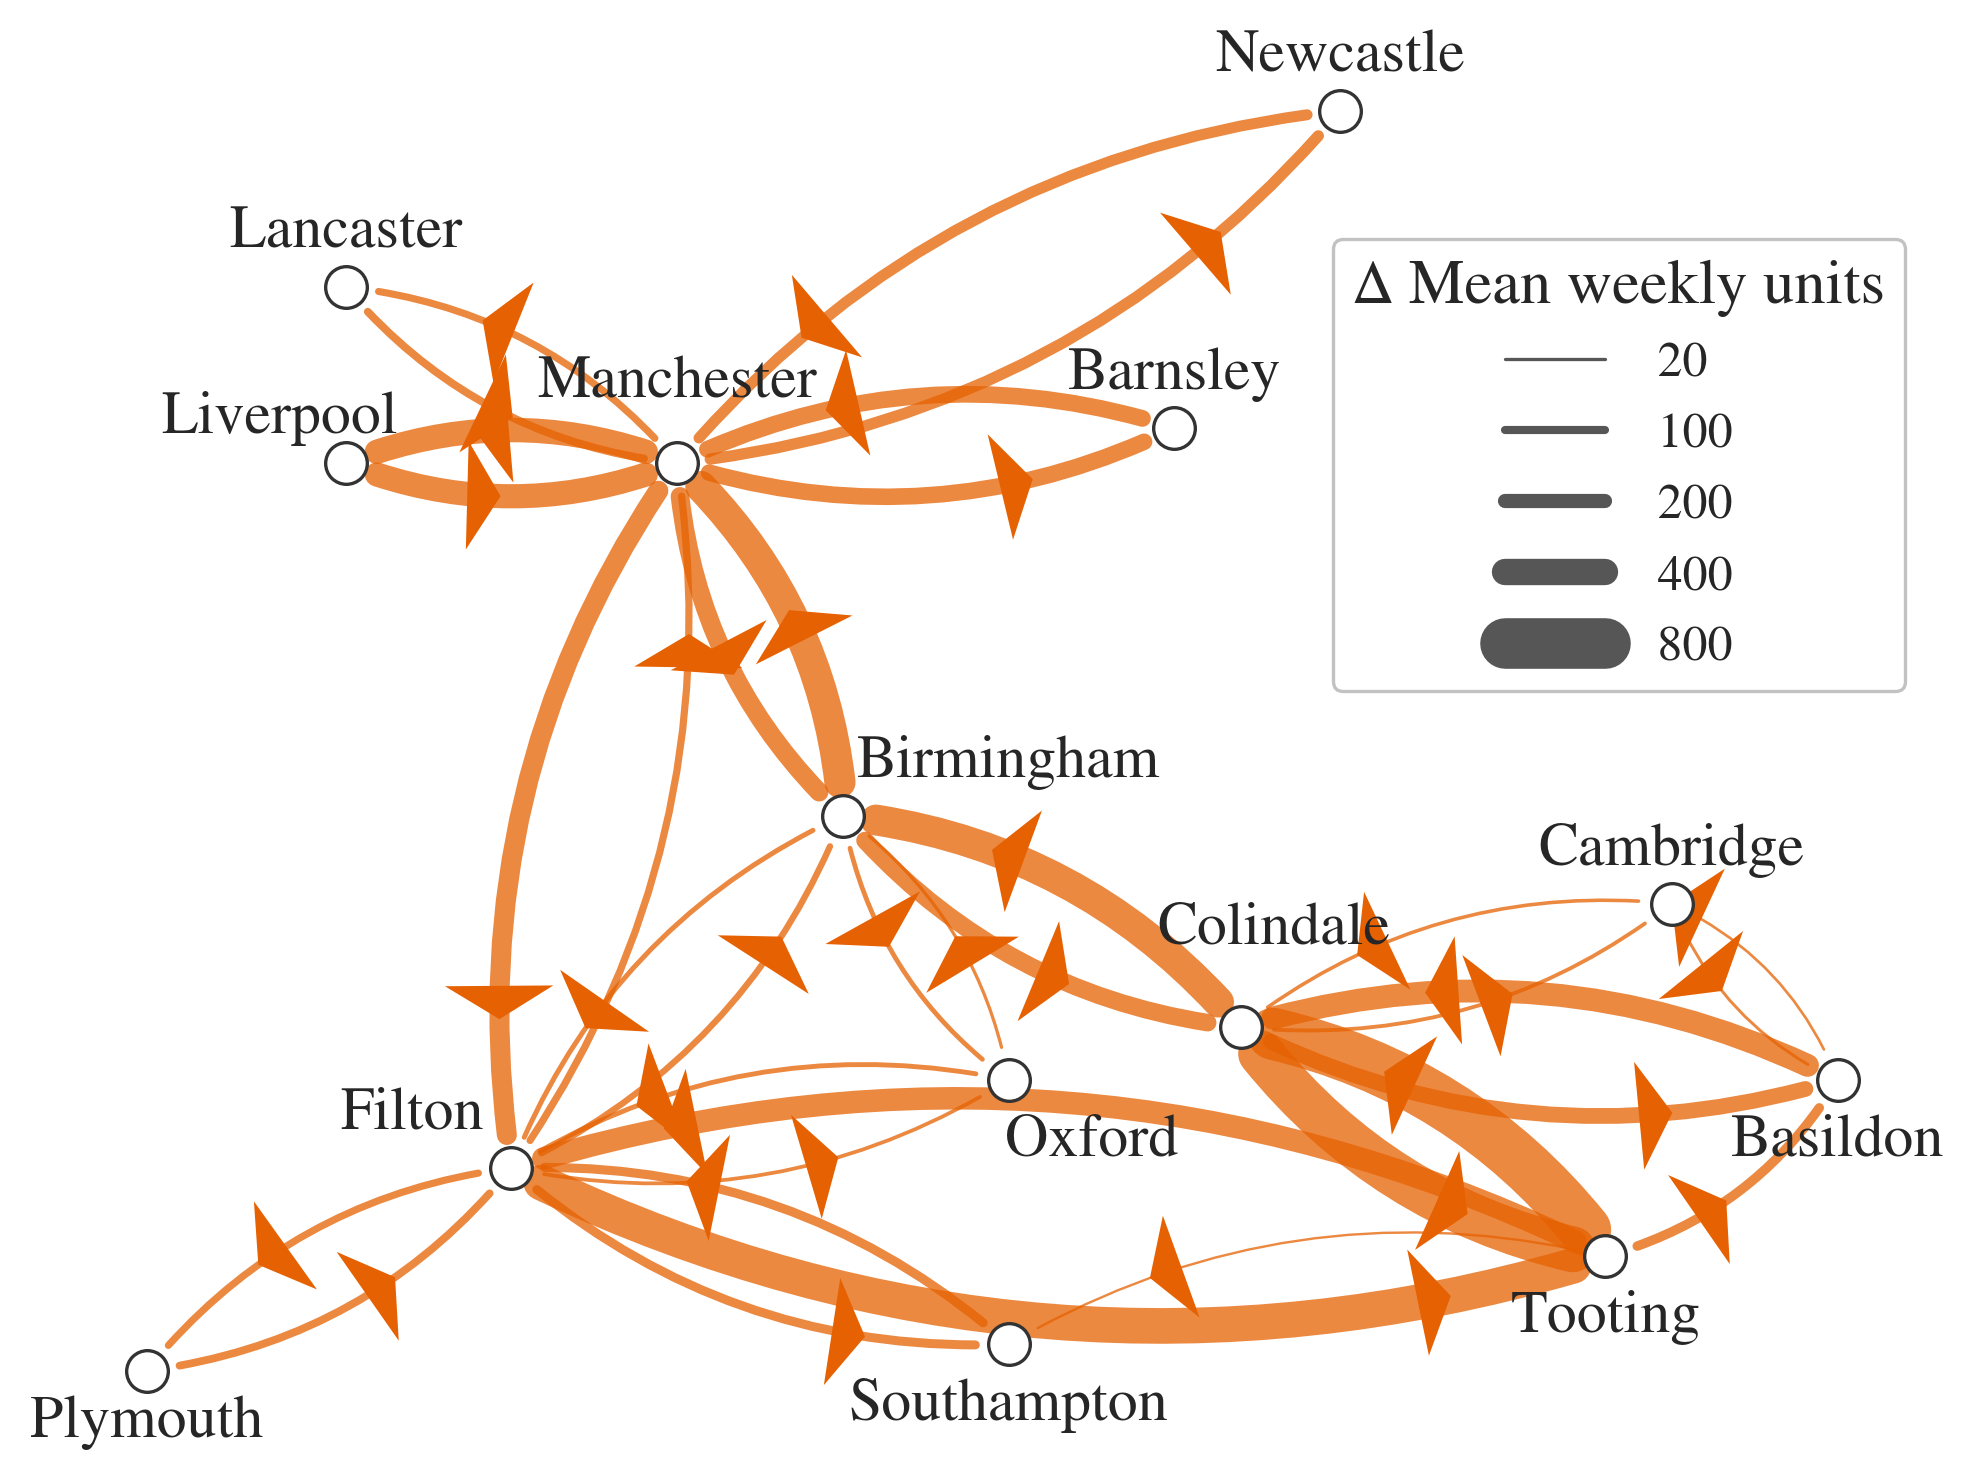

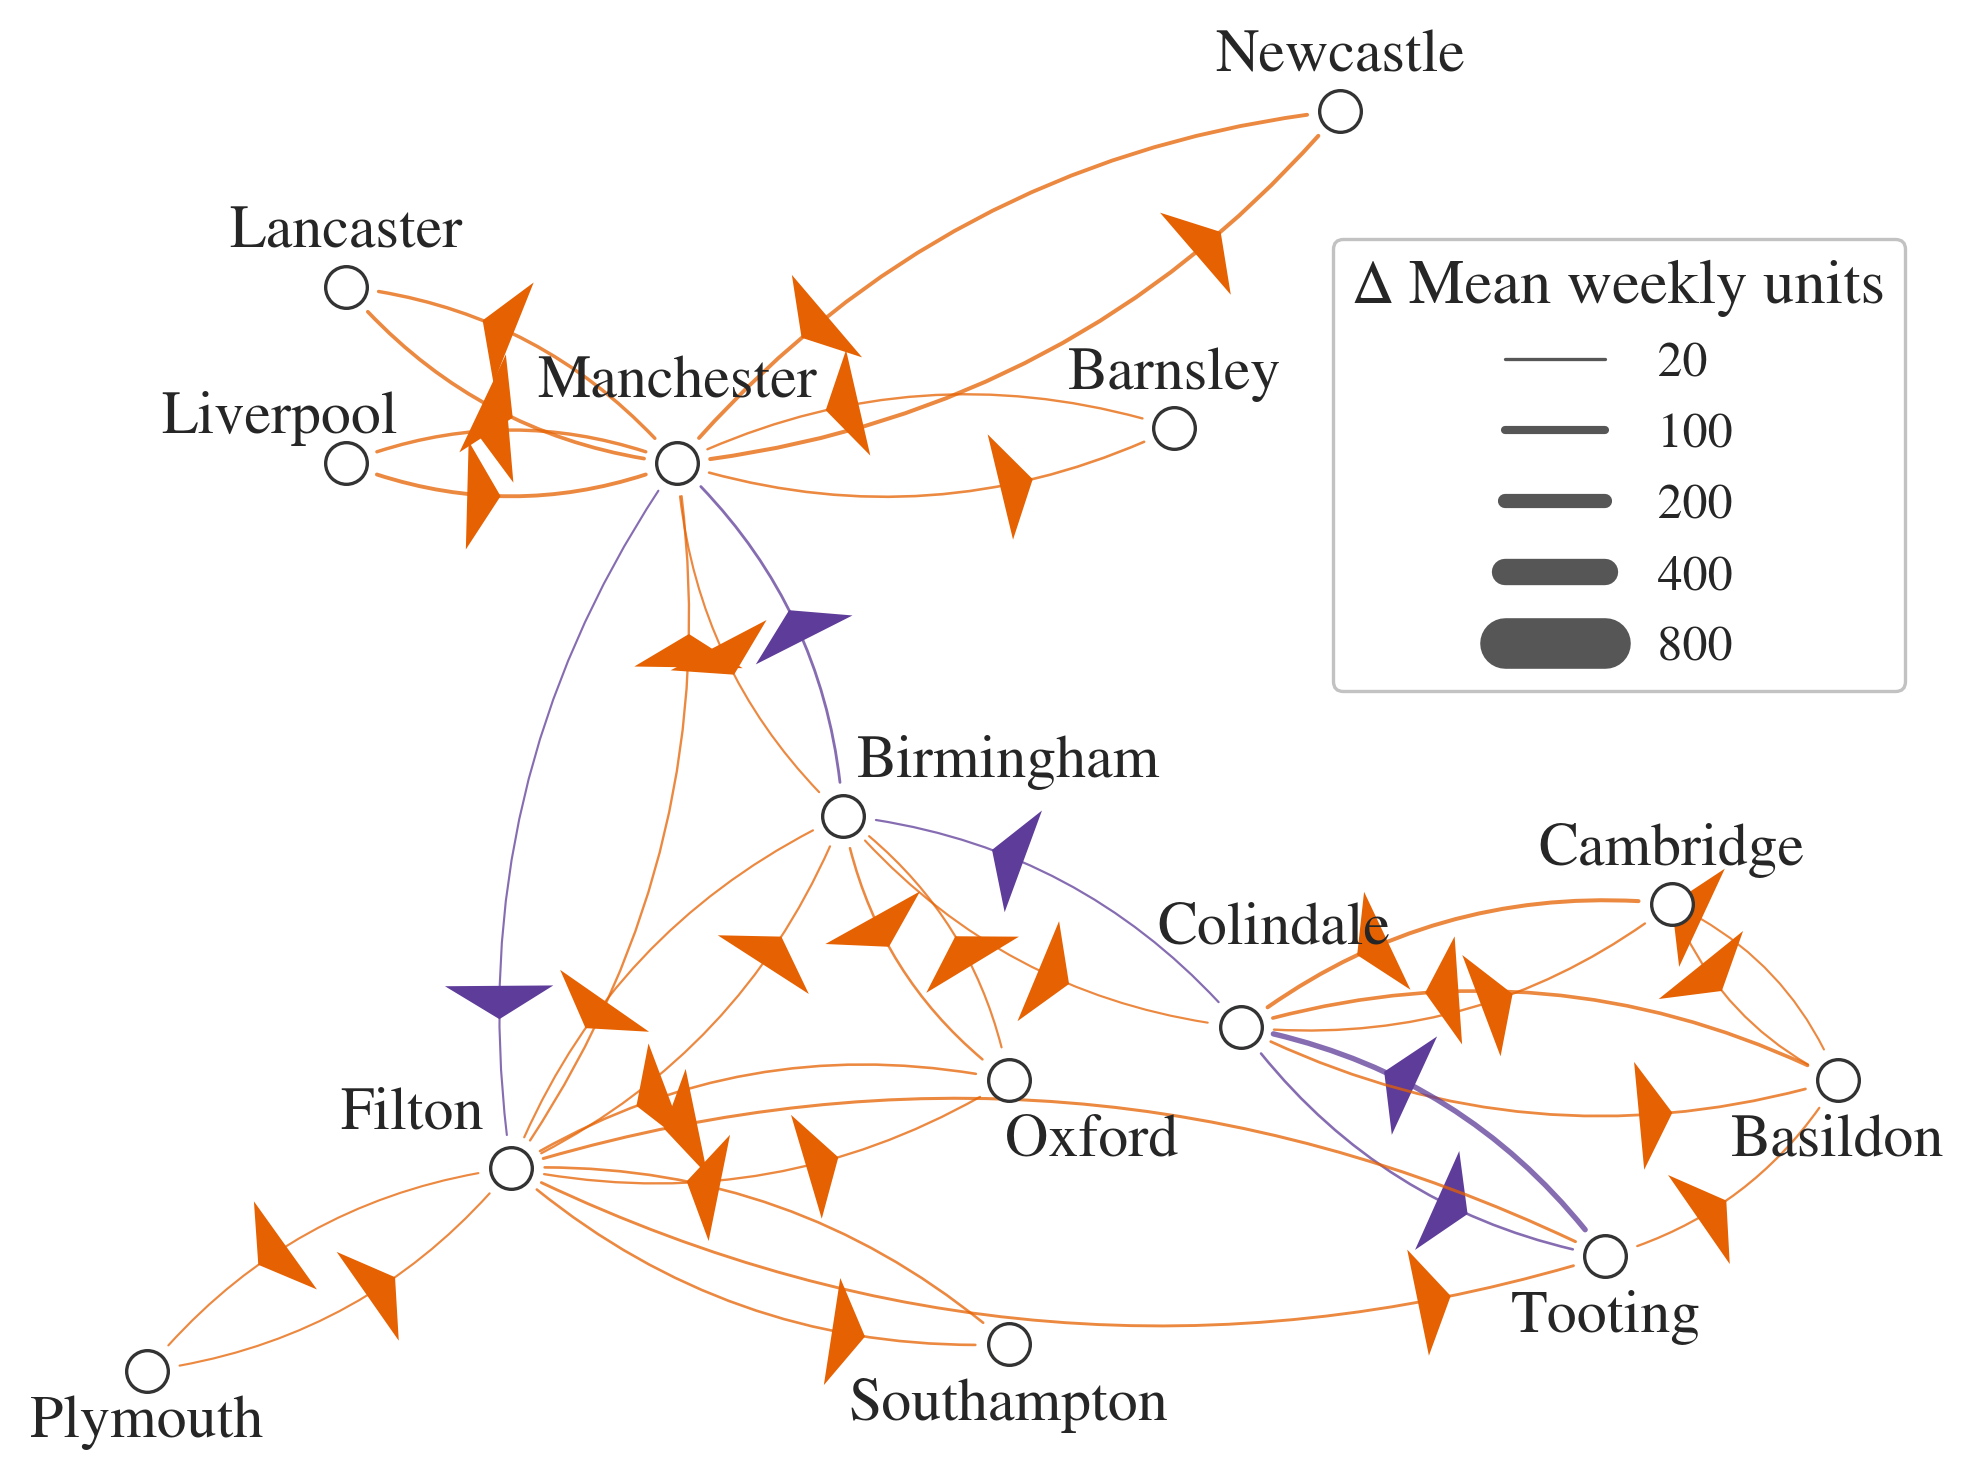

In [64]:
max_diff = logi.plot_scenario_comparison(
    e02_agg_df, l01_agg_df,
    figsize=(8, 6),
    metric_for_alpha=None,
    save_path='scratch/figures/Hermes/E02-transhipment-legs-diff-weekly.pdf'
)
_ = logi.plot_scenario_comparison(
    e03_agg_df, l01_agg_df,
    figsize=(8, 6),
    max_diff=max_diff,
    metric_for_alpha=None,
    save_path='scratch/figures/Hermes/E03-transhipment-legs-diff-weekly.pdf'
)

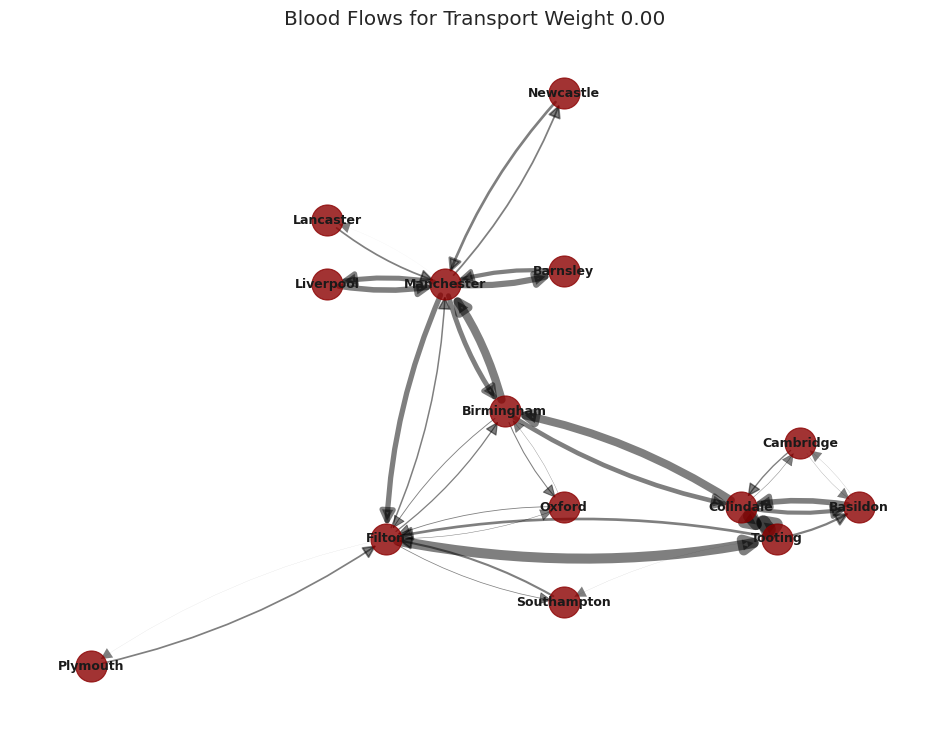

In [ ]:
# logi.plot_blood_flows(df=capacity_dfs['transport_weight_0_00'], custom_title='Blood Flows for Transport Weight 0.00',
#                     #   figsize=(12, 8), dpi=300,
#                       )

In [47]:
capacity_dfs['transport_weight_0_00']

,Origin,Destination,Mean_Weekly_Units,Std_Error,n_reps
33,Tooting,Colindale,254.362778,0.878765,100
12,Colindale,Tooting,212.590556,0.811821,100
18,Filton,Tooting,184.042222,2.255045,100
5,Birmingham,Manchester,150.209444,0.749574,100
10,Colindale,Birmingham,146.333889,0.906256,100
21,Manchester,Barnsley,113.342778,0.777035,100
2,Basildon,Colindale,102.574444,0.523004,100
20,Liverpool,Manchester,101.705000,1.134570,100
23,Manchester,Filton,96.669444,1.211515,100
25,Manchester,Liverpool,91.846111,0.830436,100


In [59]:
vehicle_capacity = 120
for scenario, df in capacity_dfs.items():
    print(f"Scenario: {scenario}")
    capacity_headroom = vehicle_capacity - df['Mean_Weekly_Units']
    print(df.loc[capacity_headroom < 0])
    print("\n")

Scenario: transport_weight_0_00
       Origin Destination  Mean_Weekly_Units  Std_Error  n_reps     Std_Dev  \
0   Colindale  Birmingham         426.416667  11.335488     100  112.786680   
1  Birmingham  Manchester         271.806667   6.260486     100   62.291054   
2     Tooting      Filton         263.760000   5.378917     100   53.519546   
3     Tooting   Colindale         250.221667   6.200165     100   61.690865   
4      Filton     Tooting         168.501667   2.445766     100   24.335063   
5  Manchester   Liverpool         149.538333   4.853267     100   48.289399   
6    Basildon   Colindale         146.638333   2.695202     100   26.816921   
7  Manchester      Filton         144.846667   2.072074     100   20.616871   
8   Colindale     Tooting         138.433333   1.208065     100   12.020099   
9      Filton     Tooting         123.886667   1.210091     100   12.040254   

    Dep_Day  Dep_Time  
0  Thursday  21:30:00  
1    Friday  01:00:00  
2    Friday  03:00:00  
3 